# 01 — Data Loading & Cleaning
**Author:** Pasindu Malinda

**Pipeline:** HDFS raw CSV → Schema validation → Per-dataset cleaning → Logical integrity checks → Core join → HDFS Parquet + local CSV sample


## 1. Environment Setup & Spark Session

In [1]:
import os
import sys

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType, DoubleType, TimestampType, BooleanType
)

spark = (
    SparkSession.builder
    .appName("ecommerce-01-data-loading-cleaning")
    .master("local[*]")
    .config("spark.hadoop.fs.defaultFS", "hdfs://localhost:9000")
    # keep shuffle partitions small — dataset is ~100k rows, not billions
    .config("spark.sql.shuffle.partitions", "8")
    # enable adaptive query execution (Spark 3+)
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} ready  |  cores: {spark.sparkContext.defaultParallelism}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/22 09:10:47 WARN Utils: Your hostname, Pasindus-MacBook-Pro-2.local, resolves to a loopback address: 127.0.0.1; using 192.168.8.188 instead (on interface en0)
26/04/22 09:10:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/22 09:10:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.1 ready  |  cores: 8


In [14]:
# ── plot libraries (standard in Jupyter environments)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# consistent style across all plots
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
TITLE_PAD = 14
FIG_DPI   = 120

print('Plot libraries ready')

Plot libraries ready


## 2. Path Configuration

In [2]:
HDFS_RAW     = "hdfs://localhost:9000/ecommerce/raw"
HDFS_OUTPUT  = "hdfs://localhost:9000/ecommerce/output"
LOCAL_OUTPUT = "/Users/pasindumalinda/Project-04/ecommerce-recommendation-spark/data/processed"

os.makedirs(LOCAL_OUTPUT, exist_ok=True)

print(f"HDFS raw    : {HDFS_RAW}")
print(f"HDFS output : {HDFS_OUTPUT}")
print(f"Local output: {LOCAL_OUTPUT}")

HDFS raw    : hdfs://localhost:9000/ecommerce/raw
HDFS output : hdfs://localhost:9000/ecommerce/output
Local output: /Users/pasindumalinda/Project-04/ecommerce-recommendation-spark/data/processed


## 3. Explicit Schema Definitions

Defining schemas explicitly avoids Spark's full-scan inference pass,
enforces correct types from the first read, and makes schema drift visible immediately.

In [3]:
schema_orders = StructType([
    StructField("order_id",                     StringType(),    False),
    StructField("customer_id",                  StringType(),    False),
    StructField("order_status",                 StringType(),    True),
    StructField("order_purchase_timestamp",      TimestampType(), True),
    StructField("order_approved_at",             TimestampType(), True),
    StructField("order_delivered_carrier_date",  TimestampType(), True),
    StructField("order_delivered_customer_date", TimestampType(), True),
    StructField("order_estimated_delivery_date", TimestampType(), True),
])

schema_order_items = StructType([
    StructField("order_id",           StringType(),    False),
    StructField("order_item_id",       IntegerType(),   True),
    StructField("product_id",          StringType(),    False),
    StructField("seller_id",           StringType(),    True),
    StructField("shipping_limit_date", TimestampType(), True),
    StructField("price",               DoubleType(),    True),
    StructField("freight_value",       DoubleType(),    True),
])

schema_products = StructType([
    StructField("product_id",                  StringType(),  False),
    StructField("product_category_name",        StringType(),  True),
    StructField("product_name_lenght",          DoubleType(),  True),  # typo is in source data
    StructField("product_description_lenght",   DoubleType(),  True),  # typo is in source data
    StructField("product_photos_qty",           DoubleType(),  True),
    StructField("product_weight_g",             DoubleType(),  True),
    StructField("product_length_cm",            DoubleType(),  True),
    StructField("product_height_cm",            DoubleType(),  True),
    StructField("product_width_cm",             DoubleType(),  True),
])

schema_customers = StructType([
    StructField("customer_id",             StringType(),  False),
    StructField("customer_unique_id",       StringType(),  True),
    StructField("customer_zip_code_prefix", IntegerType(), True),
    StructField("customer_city",           StringType(),  True),
    StructField("customer_state",          StringType(),  True),
])

schema_translation = StructType([
    StructField("product_category_name",         StringType(), True),
    StructField("product_category_name_english",  StringType(), True),
])

print("Schemas defined for 5 datasets")

Schemas defined for 5 datasets


## 4. Load Raw CSV Files from HDFS

In [4]:
READ_OPTS = {"header": "true", "timestampFormat": "yyyy-MM-dd HH:mm:ss"}

df_orders_raw = (
    spark.read.options(**READ_OPTS)
    .schema(schema_orders)
    .csv(f"{HDFS_RAW}/olist_orders_dataset.csv")
)

df_items_raw = (
    spark.read.options(**READ_OPTS)
    .schema(schema_order_items)
    .csv(f"{HDFS_RAW}/olist_order_items_dataset.csv")
)

df_products_raw = (
    spark.read.options(**READ_OPTS)
    .schema(schema_products)
    .csv(f"{HDFS_RAW}/olist_products_dataset.csv")
)

df_customers_raw = (
    spark.read.options(**READ_OPTS)
    .schema(schema_customers)
    .csv(f"{HDFS_RAW}/olist_customers_dataset.csv")
)

df_translation_raw = (
    spark.read.options(**READ_OPTS)
    .schema(schema_translation)
    .csv(f"{HDFS_RAW}/product_category_name_translation.csv")
)

print("All raw DataFrames loaded from HDFS")

All raw DataFrames loaded from HDFS


## 5. Schema & Row Count Audit

In [8]:
RAW = {
    'orders':      df_orders_raw,
    'order_items': df_items_raw,
    'products':    df_products_raw,
    'customers':   df_customers_raw,
    'translation': df_translation_raw,
}

print(f"{'Dataset':<18} {'Rows':>10} {'Columns':>9}")
print('-' * 40)
row_counts = {}
for name, df in RAW.items():
    r = df.count()
    row_counts[name] = r
    print(f"{name:<18} {r:>10,} {len(df.columns):>9}")

Dataset                  Rows   Columns
----------------------------------------
orders                 99,441         8
order_items           112,650         7
products               32,951         9
customers              99,441         5
translation                71         2


In [9]:
for name, df in RAW.items():
    print(f'\n{'='*55}')
    print(f'Schema: {name}')
    df.printSchema()


Schema: orders
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)


Schema: order_items
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)


Schema: products
root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: double (nullable = true)
 |-- product_description_lenght: double (nullabl

### 5.1 Row Count Comparison Across Datasets

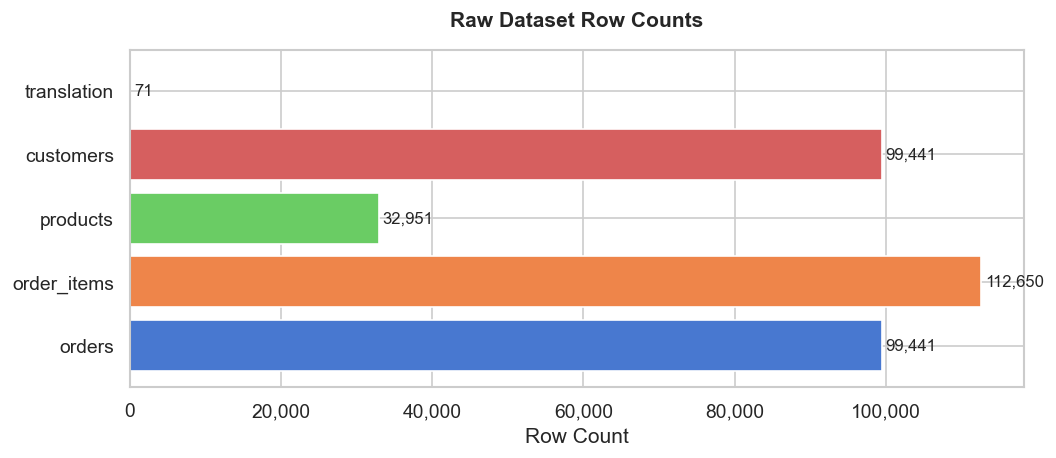

In [10]:
fig, ax = plt.subplots(figsize=(9, 4), dpi=FIG_DPI)

names  = list(row_counts.keys())
counts = list(row_counts.values())
bars   = ax.barh(names, counts, color=sns.color_palette('muted', len(names)), edgecolor='white')

for bar, val in zip(bars, counts):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Row Count')
ax.set_title('Raw Dataset Row Counts', pad=TITLE_PAD, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 6. Null / Missing Value Profiling

In [11]:
def null_audit(df, label):
    """Return null counts and % per column; print summary."""
    total = df.count()
    agg_exprs = [F.sum(F.col(c).isNull().cast('int')).alias(c) for c in df.columns]
    counts = df.select(agg_exprs).collect()[0].asDict()
    print(f'\n[{label}]  total rows: {total:,}')
    print(f"  {'Column':<45} {'Nulls':>7}  {'%':>6}")
    print(f"  {'-'*60}")
    result = {}
    for col, n in counts.items():
        pct  = n / total * 100
        flag = '  << ACTION' if n > 0 else ''
        print(f"  {col:<45} {n:>7,}  {pct:>5.1f}%{flag}")
        result[col] = pct
    return result

null_profiles = {}
for name, df in RAW.items():
    null_profiles[name] = null_audit(df, name)


[orders]  total rows: 99,441
  Column                                          Nulls       %
  ------------------------------------------------------------
  order_id                                            0    0.0%
  customer_id                                         0    0.0%
  order_status                                        0    0.0%
  order_purchase_timestamp                            0    0.0%
  order_approved_at                                 160    0.2%  << ACTION
  order_delivered_carrier_date                    1,783    1.8%  << ACTION
  order_delivered_customer_date                   2,965    3.0%  << ACTION
  order_estimated_delivery_date                       0    0.0%

[order_items]  total rows: 112,650
  Column                                          Nulls       %
  ------------------------------------------------------------
  order_id                                            0    0.0%
  order_item_id                                       0    0.0%
  produ

### 6.1 Null Percentage Heatmap

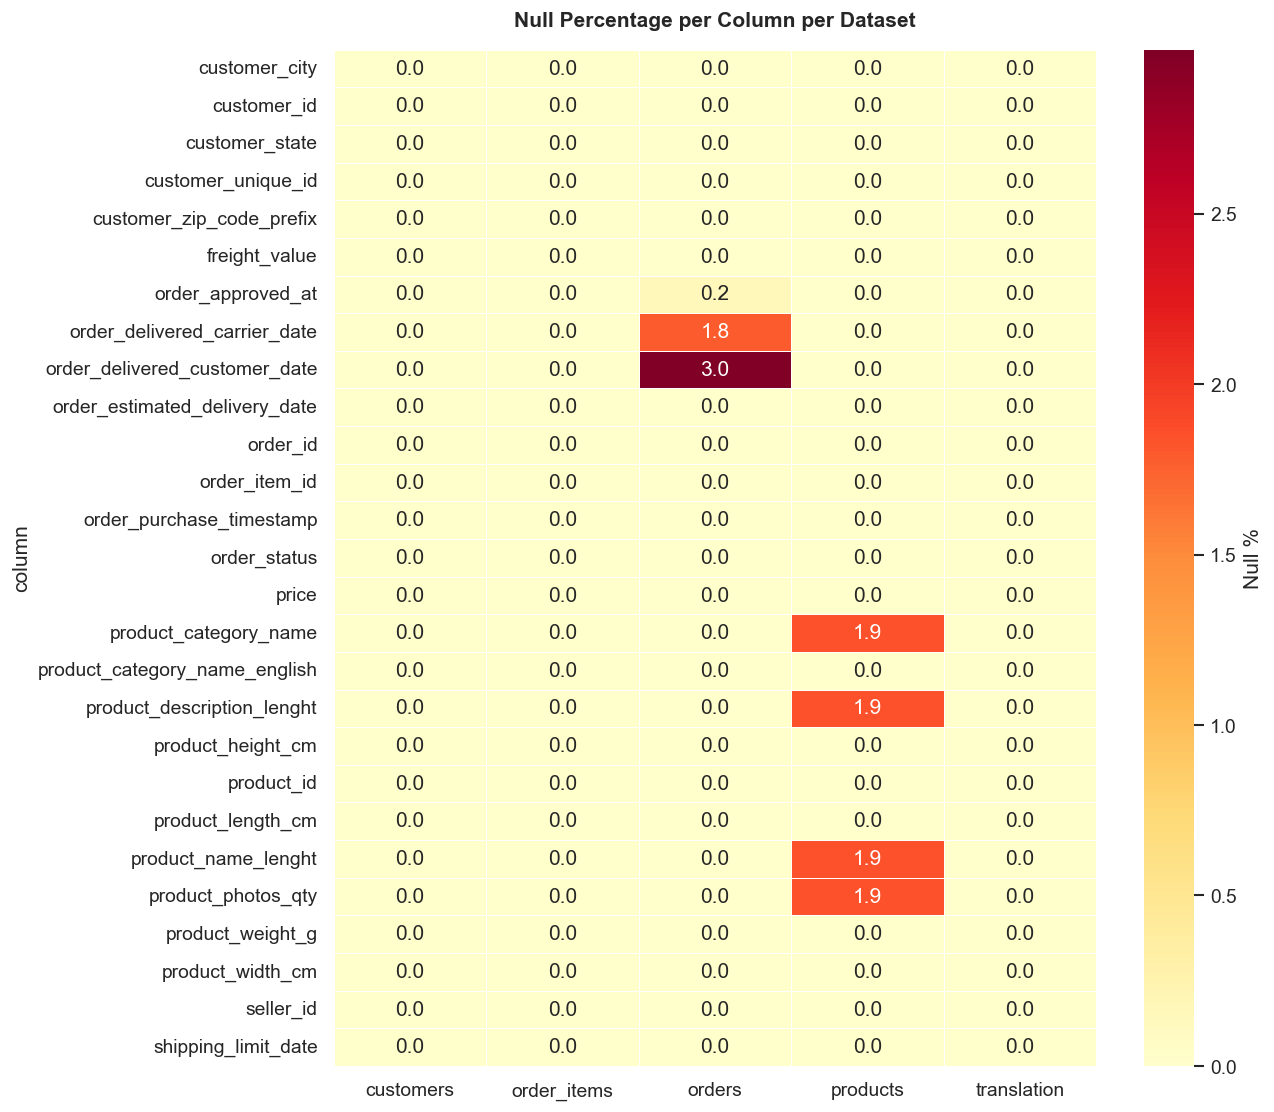

In [15]:
# collect null % into a pandas frame for heatmap
all_cols, all_vals, all_ds = [], [], []
for ds_name, profile in null_profiles.items():
    for col, pct in profile.items():
        all_cols.append(col)
        all_vals.append(pct)
        all_ds.append(ds_name)

heat_df = pd.DataFrame({'dataset': all_ds, 'column': all_cols, 'null_pct': all_vals})
heat_pivot = heat_df.pivot(index='column', columns='dataset', values='null_pct').fillna(0)

fig, ax = plt.subplots(figsize=(11, max(6, len(heat_pivot)*0.35)), dpi=FIG_DPI)
sns.heatmap(
    heat_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Null %'}
)
ax.set_title('Null Percentage per Column per Dataset', pad=TITLE_PAD, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 7. Orders — Univariate & Temporal EDA

### 7.1 Order Status Distribution

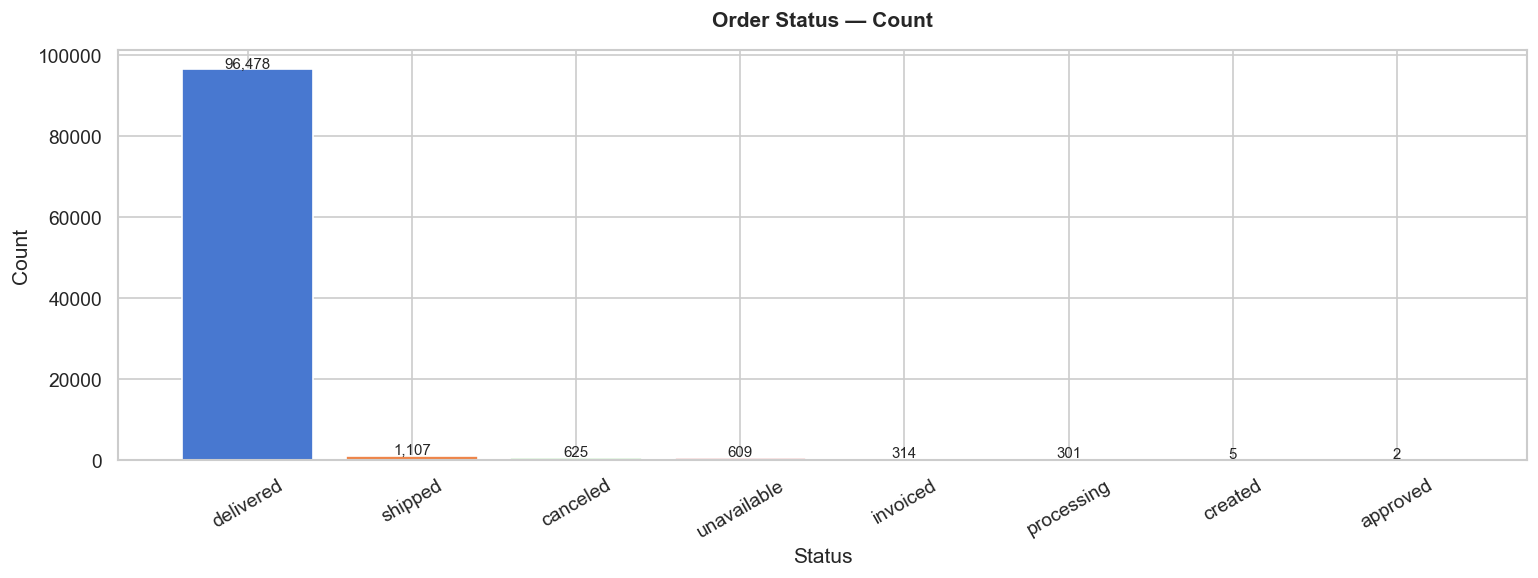

In [19]:
status_pd = (
    df_orders_raw
    .groupBy('order_status').count()
    .orderBy(F.desc('count'))
    .toPandas()
)

fig, ax = plt.subplots(figsize=(13, 5), dpi=FIG_DPI)

bars = ax.bar(status_pd['order_status'], status_pd['count'],
              color=sns.color_palette('muted', len(status_pd)),
              edgecolor='white')

for bar, val in zip(bars, status_pd['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', fontsize=9)

ax.set_title('Order Status — Count', pad=TITLE_PAD, fontweight='bold')
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()